In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
with open('city_day.csv') as city_day:
    air_q = pd.read_csv(city_day,
        parse_dates = ['Date'],
        index_col = 'Date'
    )

In [3]:
air_q.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 29531 entries, 2015-01-01 to 2020-07-01
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   PM2.5       24933 non-null  float64
 2   PM10        18391 non-null  float64
 3   NO          25949 non-null  float64
 4   NO2         25946 non-null  float64
 5   NOx         25346 non-null  float64
 6   NH3         19203 non-null  float64
 7   CO          27472 non-null  float64
 8   SO2         25677 non-null  float64
 9   O3          25509 non-null  float64
 10  Benzene     23908 non-null  float64
 11  Toluene     21490 non-null  float64
 12  Xylene      11422 non-null  float64
 13  AQI         24850 non-null  float64
 14  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(2)
memory usage: 3.6+ MB


In [4]:
air_q.City.unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

## Изучим данные в рамках одного города и параметра SO2

In [5]:
SO2_data = air_q[['City', 'SO2']][air_q['City'] == 'Thiruvananthapuram']

In [6]:
SO2_data.head()

,City,SO2
Date,,
2017-06-16,Thiruvananthapuram,4.1
2017-06-17,Thiruvananthapuram,NaN
2017-06-18,Thiruvananthapuram,NaN
2017-06-19,Thiruvananthapuram,4.5
2017-06-20,Thiruvananthapuram,NaN


<Axes: xlabel='Date'>

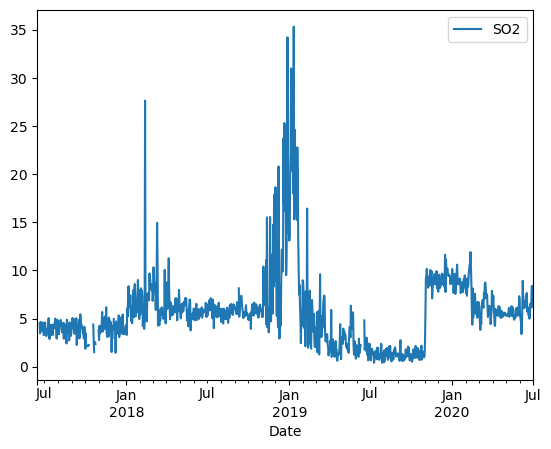

In [7]:
SO2_data.plot()

В данных есть пропуски, попробуем устранить их с помощью различных методик интерполяции

In [8]:
def compare_dists(original_data, data_without_NaNs):

    fig, ax = plt.subplots(figsize=(12, 7), dpi=140)
    sns.kdeplot(original_data, linewidth=3, ax=ax, color='black', label='Original data') #for original Series

    #for new Series with different methods of interpolaton
    for key, value in data_without_NaNs.items():               
        sns.kdeplot(value, linewidth=1, label=key, ax=ax)

    plt.legend()
    plt.show()

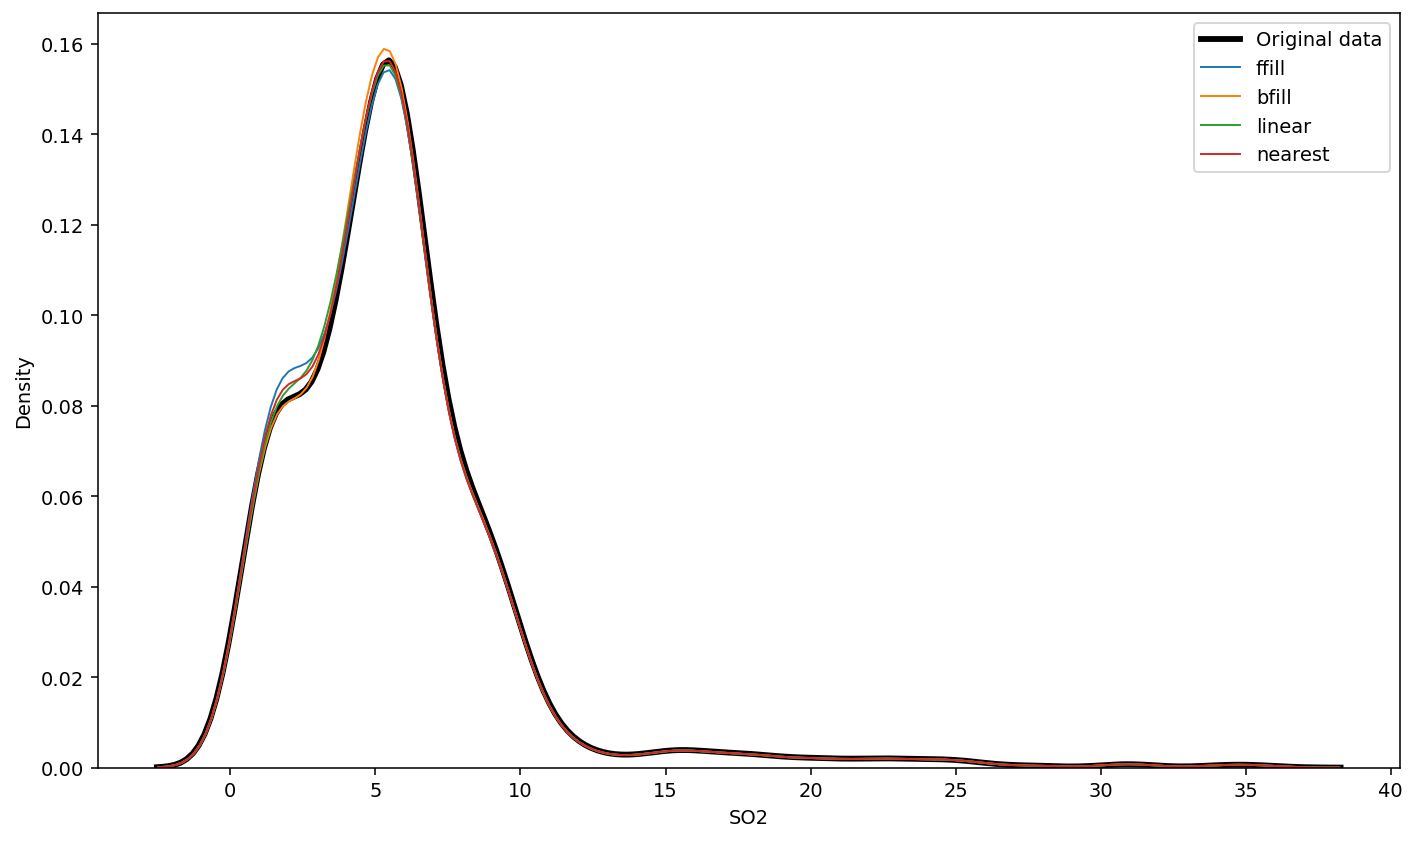

In [9]:
for method in ['ffill', 'bfill']:
    SO2_data[method] = eval(f'SO2_data.SO2.{method}()')
for method in ['linear', 'nearest']:
    SO2_data[method] = eval(f"SO2_data.SO2.interpolate(method = '{method}')")

compare_dists(SO2_data['SO2'], {'ffill': SO2_data['ffill'], 'bfill': SO2_data['bfill'], 'linear': SO2_data['linear'], 'nearest': SO2_data['nearest']})

<Axes: xlabel='Date'>

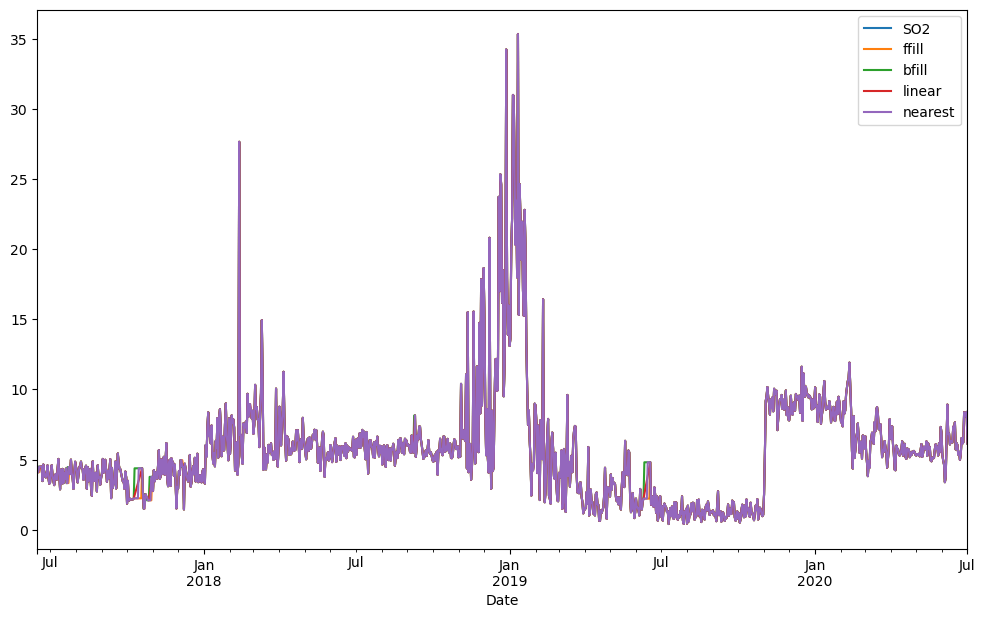

In [10]:
SO2_data.plot(figsize = (12, 7))

<Axes: xlabel='Date'>

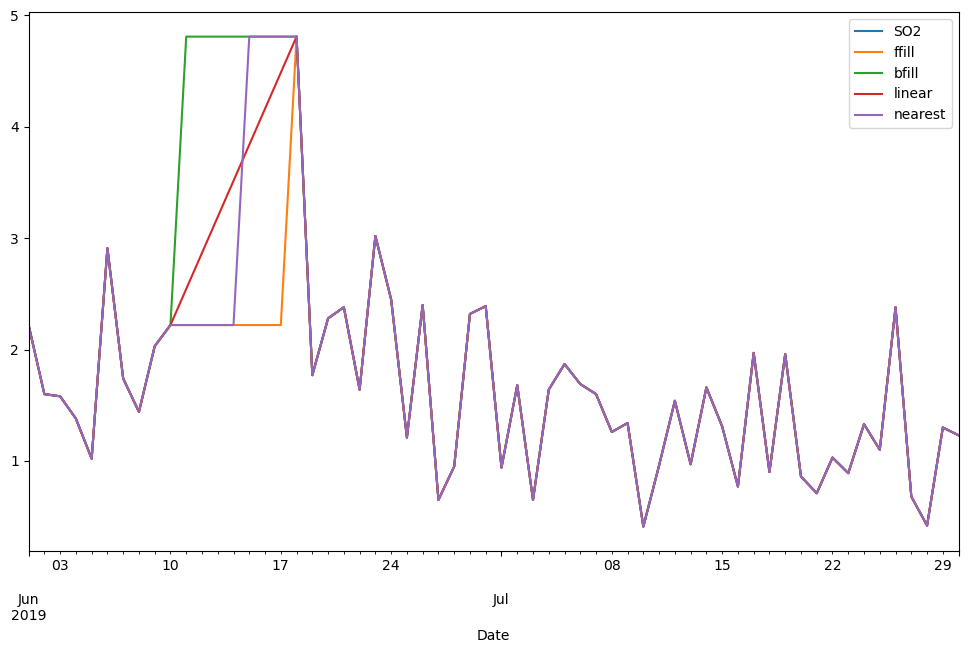

In [11]:
SO2_data['2019-06-01':'2019-07-30'].plot(figsize = (12, 7))

Будем использовать линейную интерполяцию (красная линия)

In [12]:
SO2_data_only = SO2_data.drop(['City', 'SO2', 'ffill', 'bfill', 'nearest'], axis=1)

In [13]:
SO2_data_only.columns = ['SO2']
SO2_data_only.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1112 entries, 2017-06-16 to 2020-07-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SO2     1112 non-null   float64
dtypes: float64(1)
memory usage: 49.7 KB


Имея данные с заполненными пропусками, можно обучить модель, но предварительно стоит проверить стационарность ряда

# Проверка стационарности ряда

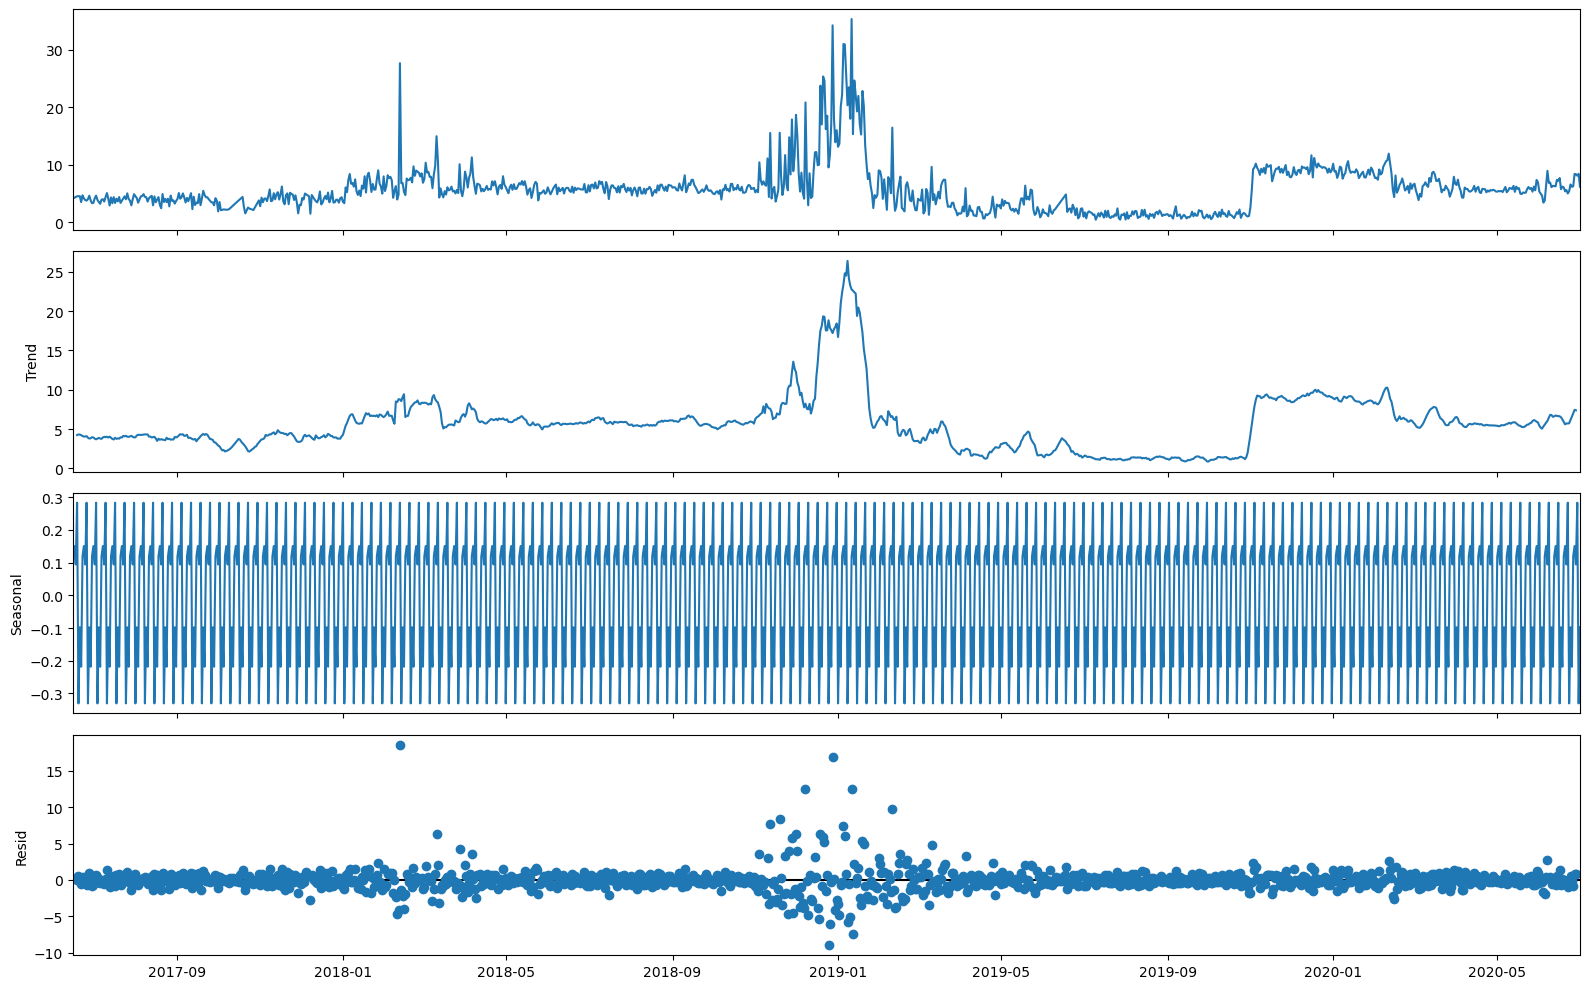

In [14]:
from matplotlib import rcParams
decomposition = sm.tsa.seasonal_decompose(SO2_data_only)
rcParams["figure.figsize"] = 16, 10
decomposition.plot();

In [15]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        ts_ax.set_title('Time Series Analysis Plots')
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)

        print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(y, regression='ct', autolag='AIC')[1])

        plt.tight_layout()
    return

In [16]:
def check_stationarity(series, name):
    result = sm.tsa.stattools.adfuller(series, regression='ct', autolag='AIC')
    print(f"\nADF-тест для {name}:")
    print(f"ADF Statistic: {result[0]:.3f}")
    print(f"p-value: {result[1]:.20f}")
    print("Критические значения:")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.3f}")
    if result[1] < 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд нестационарен (не отвергаем H0)")

In [17]:
check_stationarity(SO2_data_only, name = 'SO2')


ADF-тест для SO2:
ADF Statistic: -3.205
p-value: 0.08343017363242216655
Критические значения:
	1%: -3.967
	5%: -3.415
	10%: -3.129
Ряд нестационарен (не отвергаем H0)


Критерий Дики-Фуллера: p=0.083430


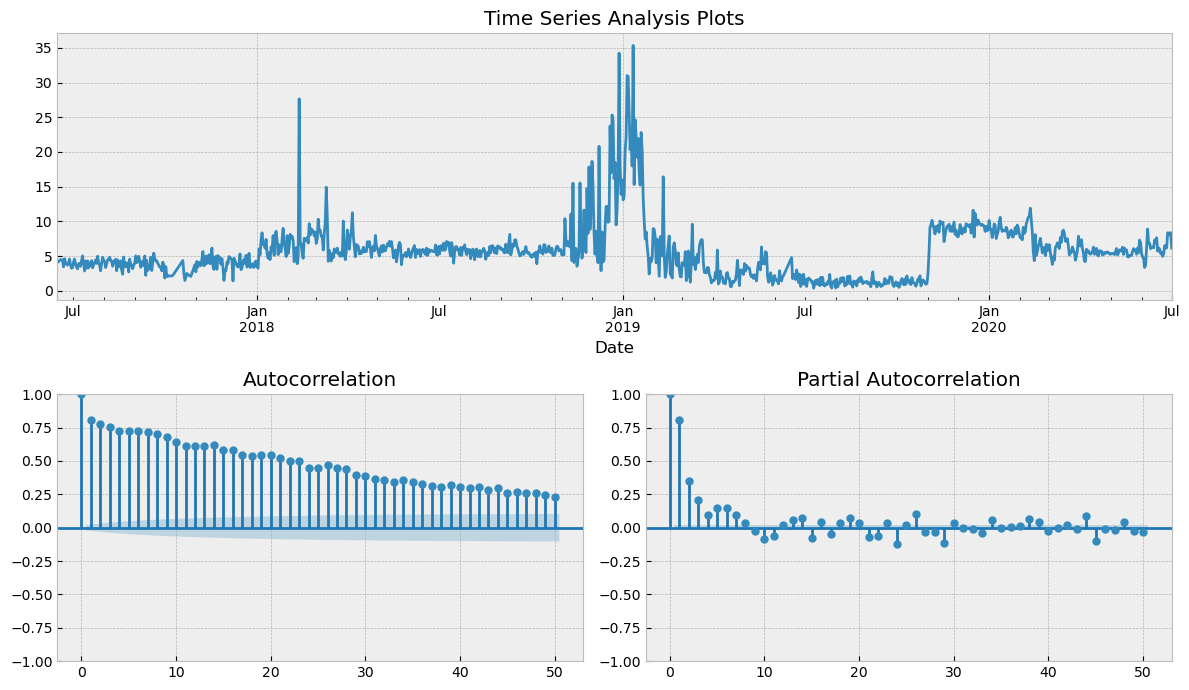

In [18]:
tsplot(SO2_data_only['SO2'], lags = 50)

In [19]:
SO2_data_only_diff = (SO2_data_only['SO2'] - SO2_data_only['SO2'].shift(1)).dropna()

In [20]:
check_stationarity(SO2_data_only_diff, name = 'SO2')


ADF-тест для SO2:
ADF Statistic: -7.173
p-value: 0.00000000572824519677
Критические значения:
	1%: -3.967
	5%: -3.415
	10%: -3.129
Ряд стационарен (отвергаем H0)


Критерий Дики-Фуллера: p=0.000000


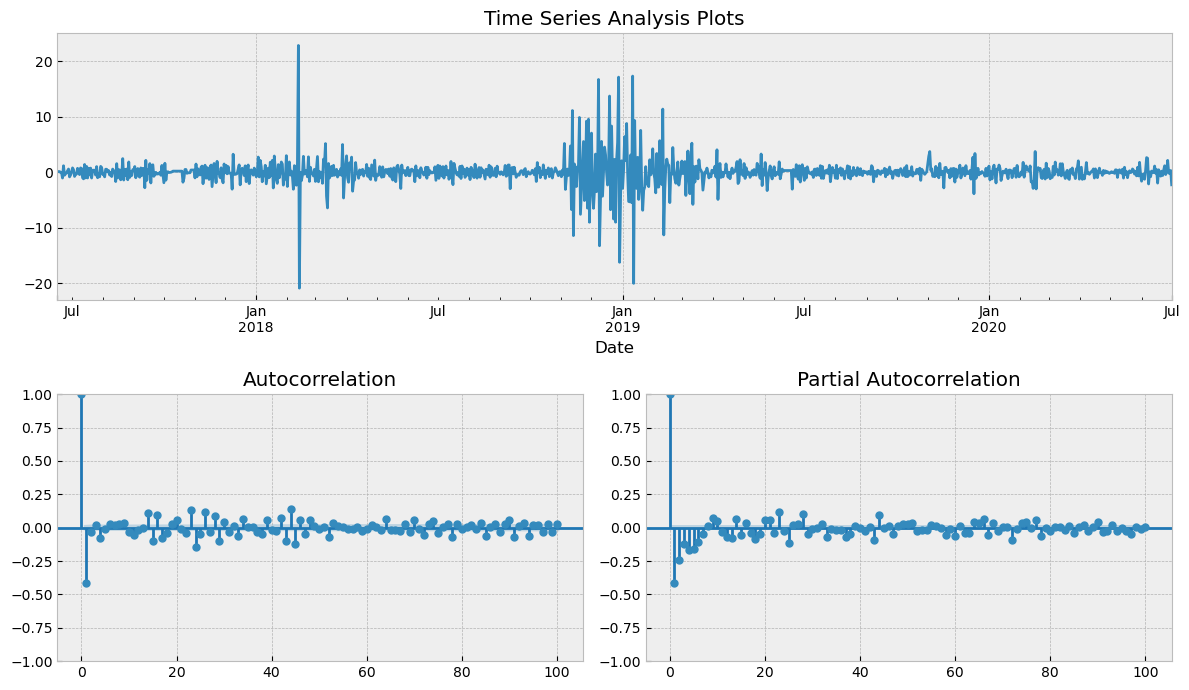

In [21]:
tsplot(SO2_data_only_diff, lags = 100)

In [22]:
SO2_data_only_diff_season = (SO2_data_only_diff - SO2_data_only_diff.shift(365)).dropna()

Критерий Дики-Фуллера: p=0.000000


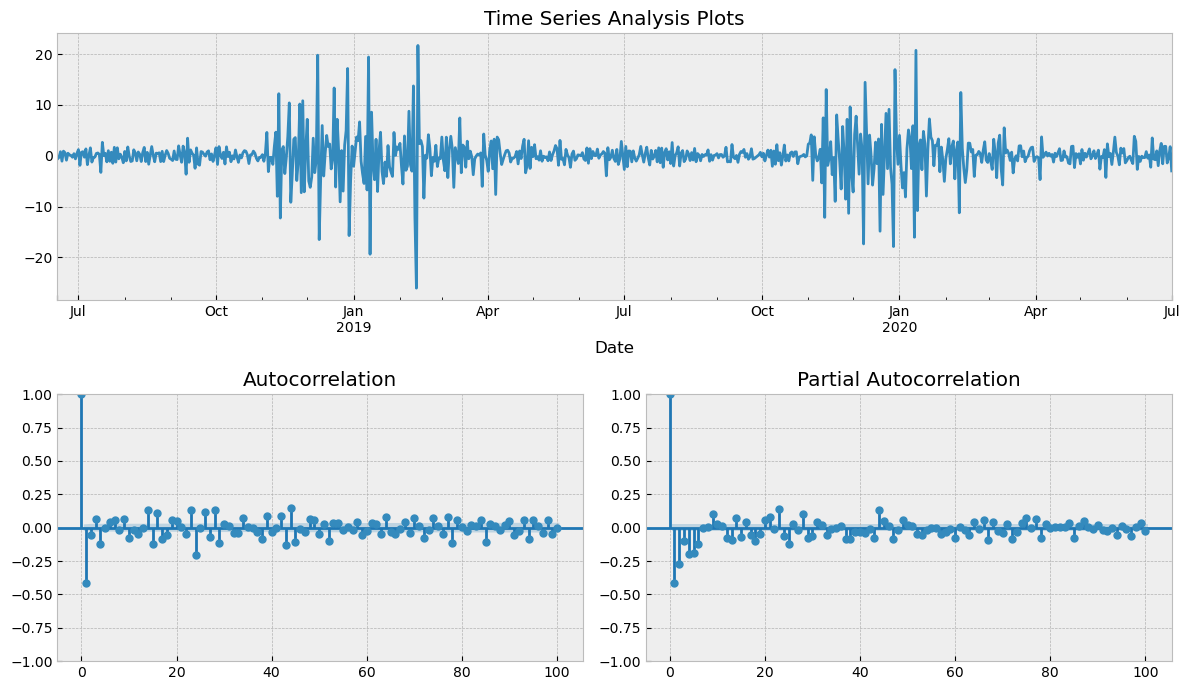

In [23]:
tsplot(SO2_data_only_diff_season, lags=100)

Автокорреляция стала больше, поэтому остановимся на данных, очищенных от тренда

## SARIMA

Подберём параметры модели

In [24]:
SO2_for_model = SO2_data_only[:'2020-06-01']

In [25]:
ps = range(1, 6)
d= 1
qs = range(1, 4)
Ps = 0
D= 0
Qs = 0
from itertools import product

parameters = product(ps, qs)
parameters_list = list(parameters)
parameters_list

[(1, 1),
 (1, 2),
 (1, 3),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 1),
 (3, 2),
 (3, 3),
 (4, 1),
 (4, 2),
 (4, 3),
 (5, 1),
 (5, 2),
 (5, 3)]

In [26]:
def get_best_params_for_SARIMA(series, param_list): 
    results = []
    best_aic = float("inf")
    
    for param in tqdm(param_list):
        try:
            model=sm.tsa.statespace.SARIMAX(series,
                                            order=(param[0], d, param[1]), 
                                            seasonal_order=(Ps, D, Qs, 0)).fit(disp=-1)
        except ValueError:
            print('wrong parameters:', param)
            continue
        aic = model.aic
        #сохраняем лучшую модель, aic, параметры
        if aic < best_aic:
            best_model = model
            best_aic = aic
            best_param = param
        results.append([param, model.aic])
    
    warnings.filterwarnings('ignore')
    
    result_table = pd.DataFrame(results)
    result_table.columns = ['parameters', 'aic']
    print(result_table.sort_values(by = 'aic', ascending=True).head(10))
get_best_params_for_SARIMA(SO2_for_model, parameters_list)

  0%|                                                                                           | 0/15 [00:00<?, ?it/s]C:\Anaconda3-2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Anaconda3-2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Anaconda3-2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Anaconda3-2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 13%|███████████                                                                        |

   parameters          aic
11     (4, 3)  4647.768990
5      (2, 3)  4648.181912
8      (3, 3)  4649.188829
13     (5, 2)  4666.067255
14     (5, 3)  4666.208788
10     (4, 2)  4667.440913
12     (5, 1)  4674.703817
9      (4, 1)  4678.728771
0      (1, 1)  4683.645282
3      (2, 1)  4685.027036


In [27]:
best_model = sm.tsa.statespace.SARIMAX(SO2_for_model, order=(4, 1, 3), 
                                        seasonal_order=(0, 0, 0, 0)).fit()

In [28]:
print(best_model.summary()) 

                               SARIMAX Results                                
Dep. Variable:                    SO2   No. Observations:                 1082
Model:               SARIMAX(4, 1, 3)   Log Likelihood               -2315.884
Date:                Thu, 07 Aug 2025   AIC                           4647.769
Time:                        11:18:03   BIC                           4687.654
Sample:                    06-16-2017   HQIC                          4662.871
                         - 06-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0261      0.044     23.394      0.000       0.940       1.112
ar.L2         -0.9235      0.037    -24.911      0.000      -0.996      -0.851
ar.L3          0.0377      0.024      1.588      0.1

Критерий Дики-Фуллера: p=0.000000


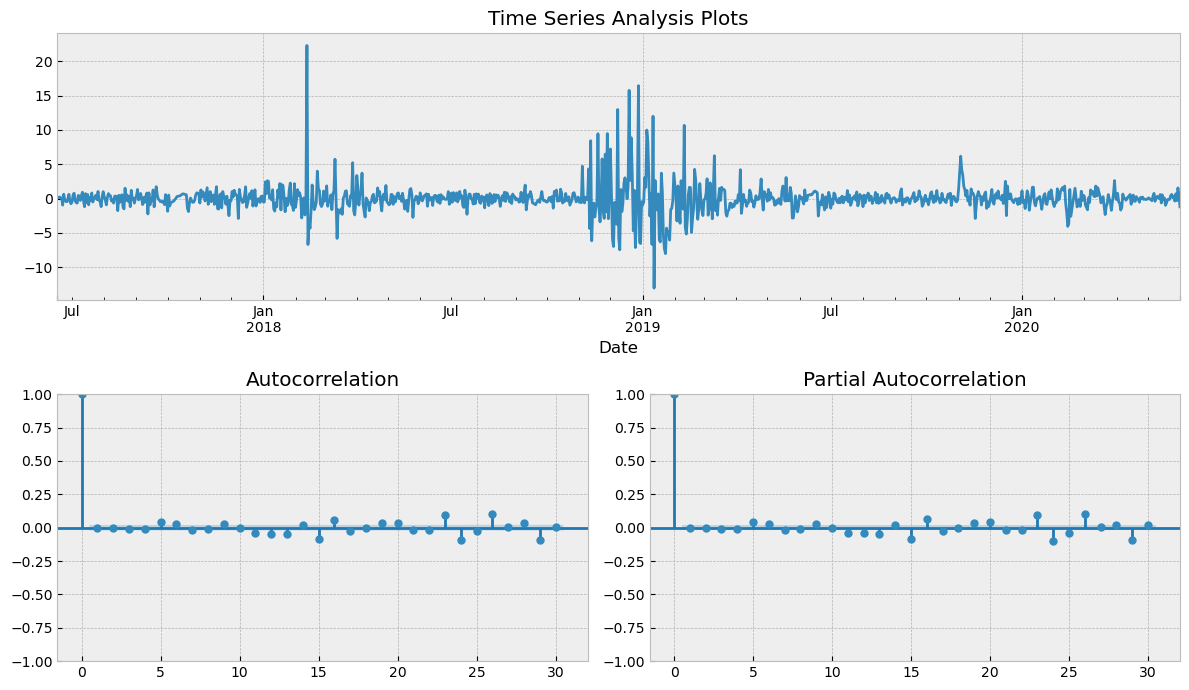

In [29]:
tsplot(best_model.resid[1:], lags=30)

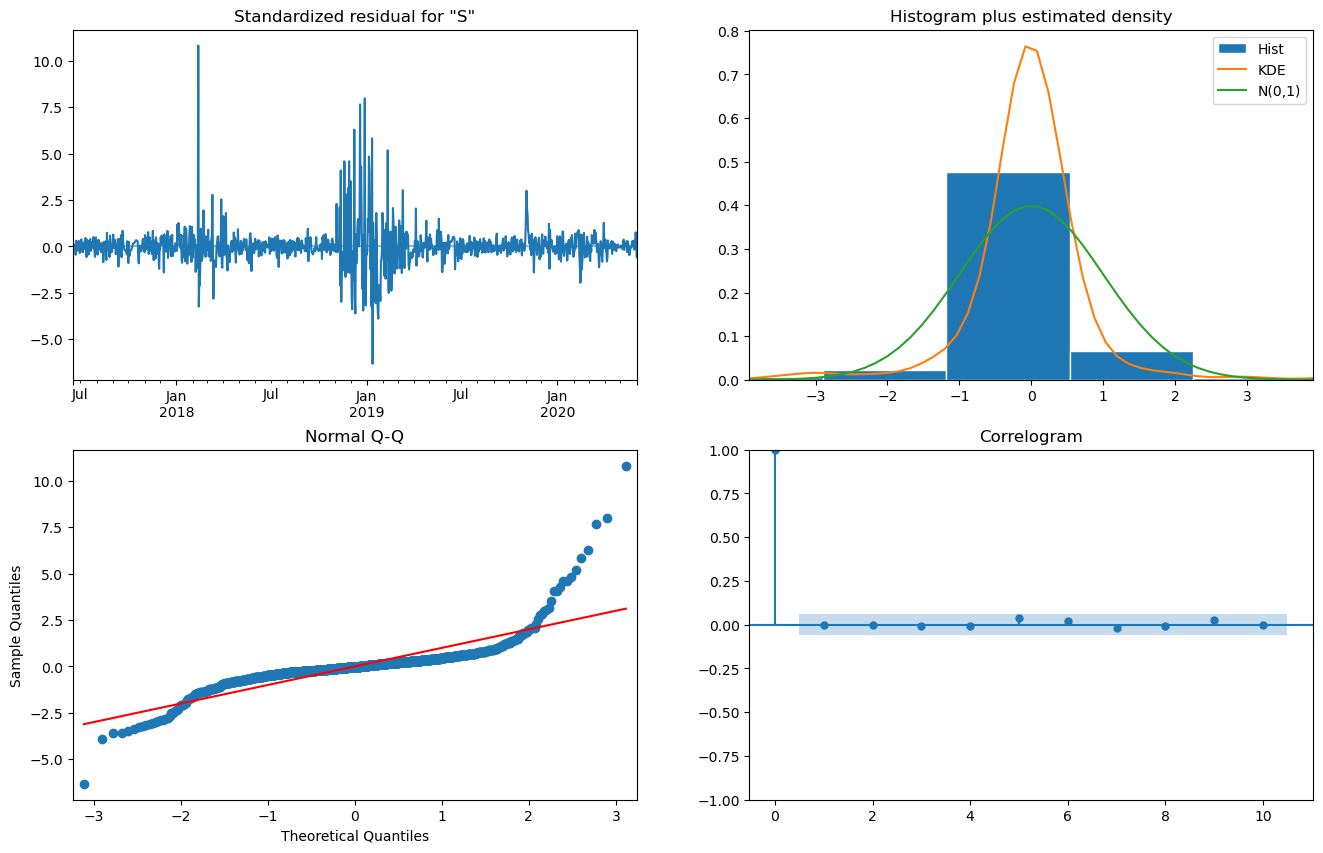

In [30]:
best_model.plot_diagnostics(figsize=(16, 10))
plt.show()

Прогноз по получившейся модели

In [31]:
SO2_dataframe = pd.DataFrame()
SO2_dataframe['SO2_seen_data'] = pd.DataFrame(SO2_for_model)
SO2_dataframe["predict_for_seen_data"] = best_model.fittedvalues
forecast = pd.DataFrame({'predict_for_unseen_data': best_model.predict(start = SO2_for_model.shape[0]-1, end = SO2_data_only.shape[0])})
unseen_data = pd.DataFrame({'SO2_unseen_data': SO2_data_only.SO2['2020-06-01':]})
SO2_dataframe = SO2_dataframe.join(unseen_data, how = 'outer')
SO2_dataframe = SO2_dataframe.join(forecast)


SARIMA model
 Mean absolute error seen data: 25.08%
 Mean absolute error unseen data: 16.44%


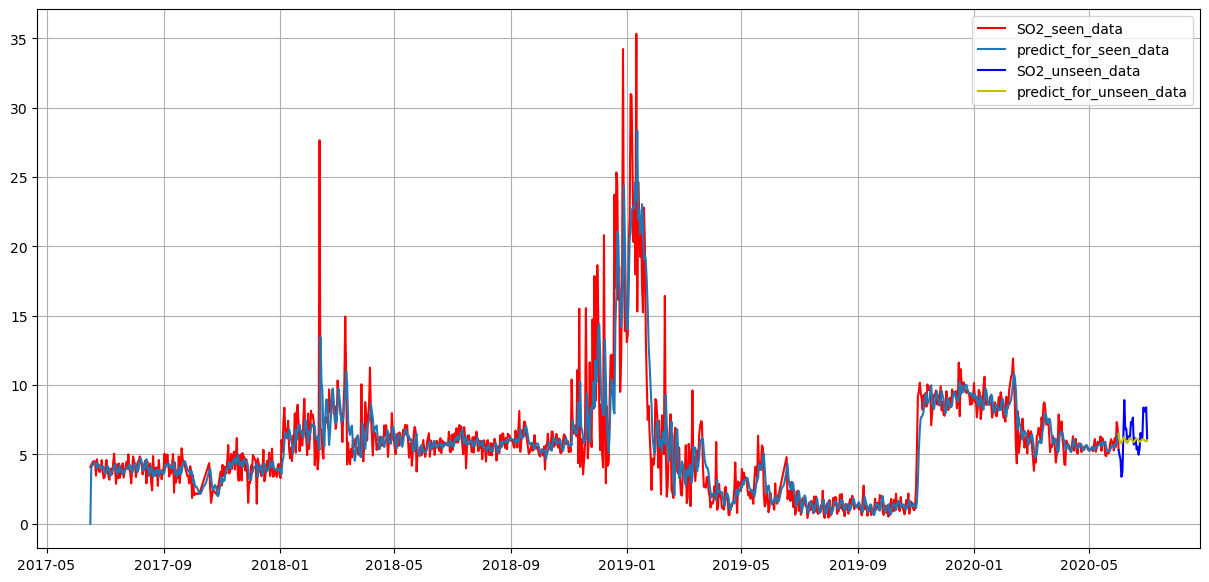

In [32]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def make_final_plot(data):
    plt.figure(figsize=(15, 7))
    plt.plot(data['SO2_seen_data'], color='r', label="SO2_seen_data")
    plt.plot(data["predict_for_seen_data"], label="predict_for_seen_data")
    plt.plot(data['SO2_unseen_data'], color='b', label="SO2_unseen_data")
    plt.plot(data['predict_for_unseen_data'], color='y', label="predict_for_unseen_data")
    plt.legend()
    plt.grid(True)
    print(f'SARIMA model\n Mean absolute error seen data: {round(mean_absolute_percentage_error(data.SO2_seen_data.dropna(), data.predict_for_seen_data.dropna()),2)}%'
          f'\n Mean absolute error unseen data: {round(mean_absolute_percentage_error(data.SO2_unseen_data.dropna()[1:], data.predict_for_unseen_data.dropna()),2)}%')
make_final_plot(SO2_dataframe)

Получившиеся значения отклонений довольно большие. Это может быть связано с выбросами в данных. Попробуем получить лучшие значения при помощи предварительного сглаживания временного ряда. В качестве исходного ряда возьмём ряд с заполненными пропущенными значениями

# Прогнозирование на основе сглаженного ряда

In [33]:
SO2_data_rolling = SO2_data_only.rolling(7).mean().dropna()

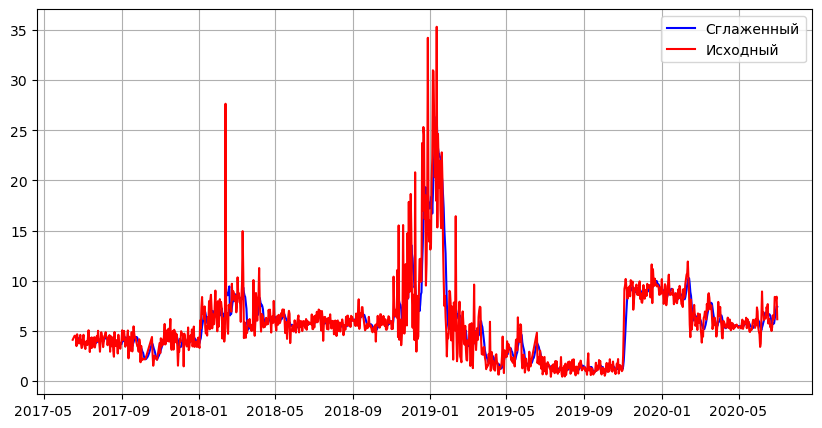

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(SO2_data_rolling, color = 'b', label = 'Сглаженный')
plt.plot(SO2_data_only, color = 'r', label = 'Исходный')
plt.legend()
plt.grid(True)

Укрупнение в окрестности начала 2019 года

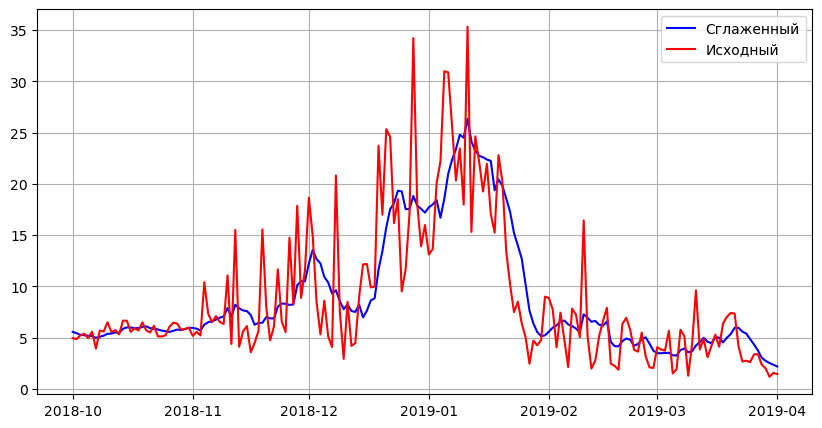

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(SO2_data_rolling['2018-10-01':'2019-04-01'], color = 'b', label = 'Сглаженный')
plt.plot(SO2_data_only['2018-10-01':'2019-04-01'], color = 'r', label = 'Исходный')
plt.legend()
plt.grid()

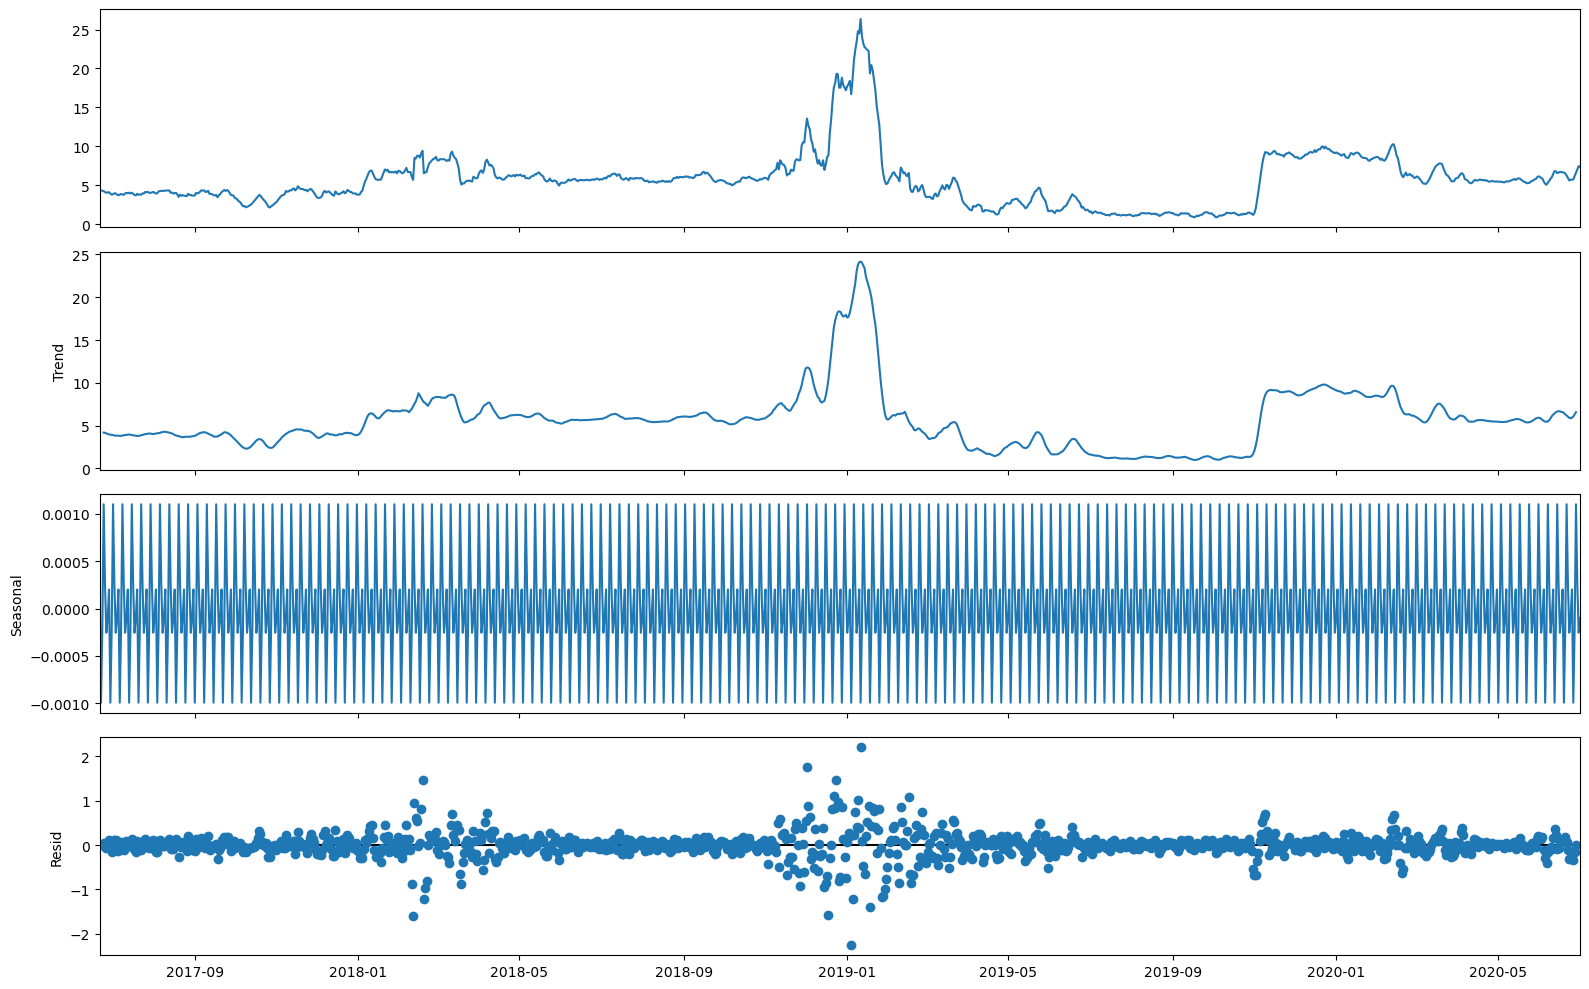

In [36]:
decomposition = sm.tsa.seasonal_decompose(SO2_data_rolling)
rcParams["figure.figsize"] = 16, 10
decomposition.plot();


ADF-тест для SO2:
ADF Statistic: -3.384
p-value: 0.05355473879009368249
Критические значения:
	1%: -3.967
	5%: -3.415
	10%: -3.129
Ряд нестационарен (не отвергаем H0)
Критерий Дики-Фуллера: p=0.053555


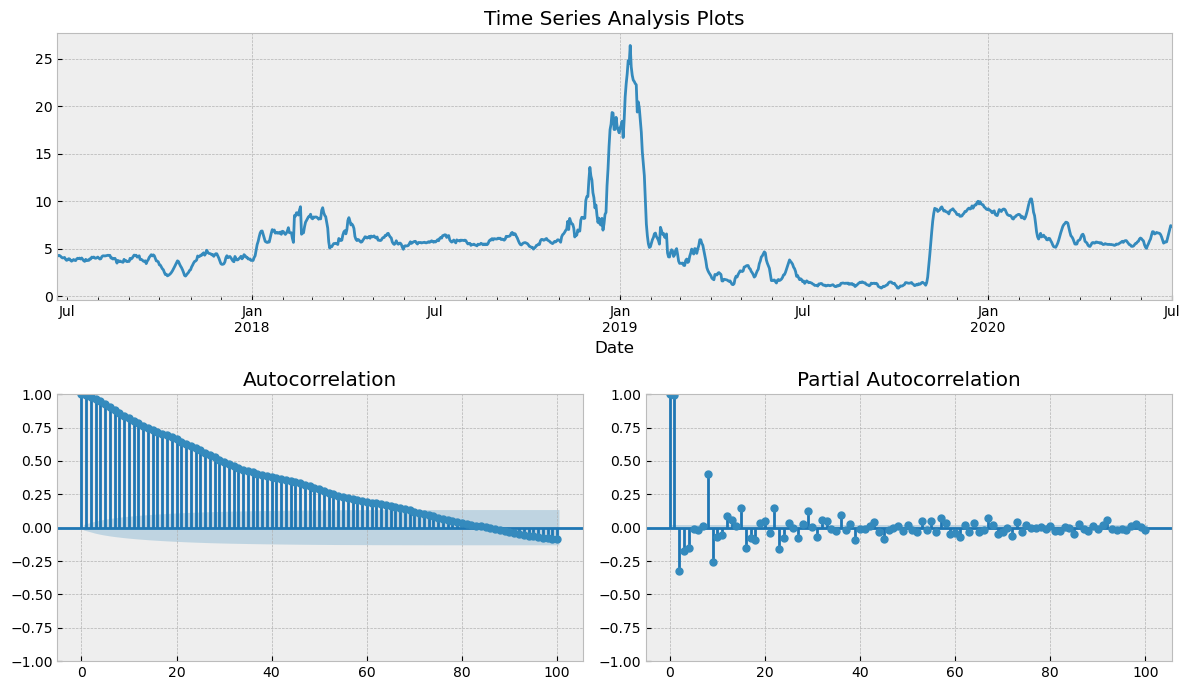

In [37]:
check_stationarity(SO2_data_rolling, name = 'SO2')
tsplot(SO2_data_rolling.SO2, lags = 100)

Проведём дифференцирование ряда


ADF-тест для SO2:
ADF Statistic: -6.055
p-value: 0.00000168313421191480
Критические значения:
	1%: -3.967
	5%: -3.415
	10%: -3.129
Ряд стационарен (отвергаем H0)
Критерий Дики-Фуллера: p=0.000002


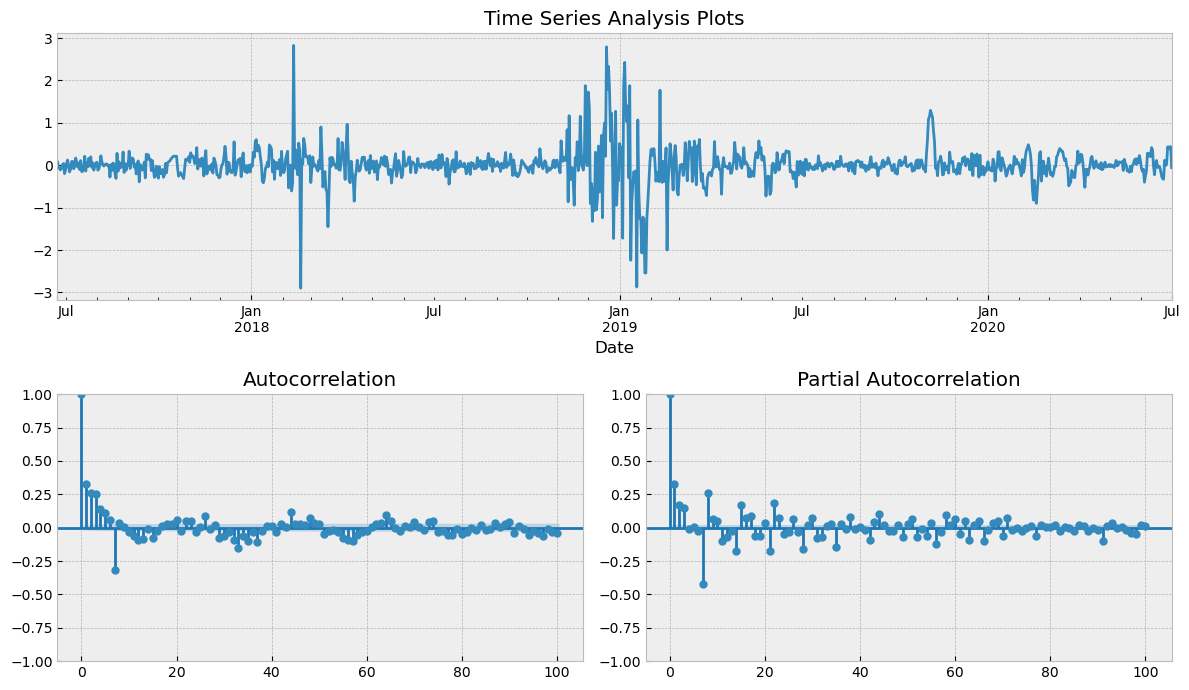

In [38]:
SO2_data_rolling_diff = (SO2_data_rolling['SO2'] - SO2_data_rolling['SO2'].shift(1)).dropna()
check_stationarity(SO2_data_rolling_diff, name = 'SO2')
tsplot(SO2_data_rolling_diff, lags = 100)

Критерий Дики-Фуллера: p=0.028195


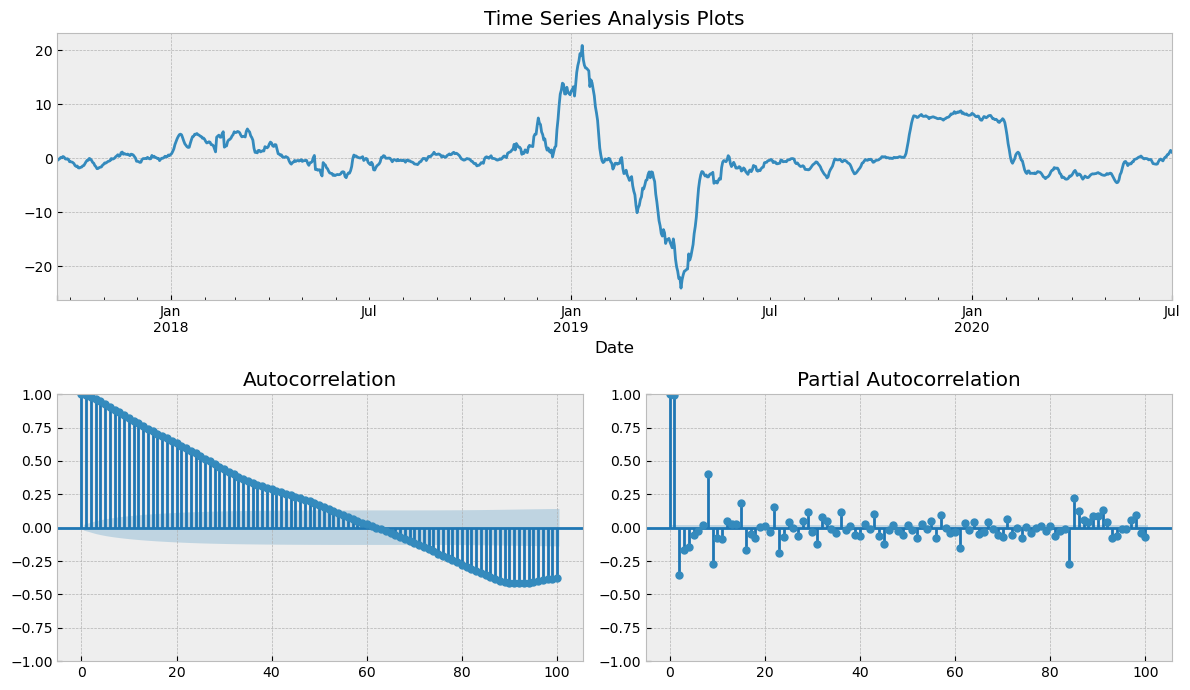

In [39]:
SO2_data_only_diff_season = (SO2_data_rolling - SO2_data_rolling.shift(90)).dropna()
tsplot(SO2_data_only_diff_season.SO2, lags=100)

Как и в случае с несглаженным рядом, видим, что предположение о сезонности в данных не оправдывается. Воспользуемся имеющимся списком предполагаемых параметров модели

In [40]:
SO2_data_rolling_for_model = SO2_data_rolling[:'2020-06-01']

In [41]:
get_best_params_for_SARIMA(SO2_data_rolling_for_model, parameters_list)

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:07<00:00,  2.02it/s]

   parameters          aic
13     (5, 2)   833.371896
11     (4, 3)   891.886593
8      (3, 3)   911.038019
14     (5, 3)   915.560187
5      (2, 3)   916.129478
4      (2, 2)   962.496356
2      (1, 3)  1024.292257
6      (3, 1)  1041.062374
7      (3, 2)  1043.055741
9      (4, 1)  1043.059905


In [42]:
best_model_rolling = sm.tsa.statespace.SARIMAX(SO2_data_rolling_for_model, order=(5, 1, 2)).fit()

In [43]:
print(best_model_rolling.summary())

                               SARIMAX Results                                
Dep. Variable:                    SO2   No. Observations:                 1076
Model:               SARIMAX(5, 1, 2)   Log Likelihood                -408.686
Date:                Thu, 07 Aug 2025   AIC                            833.372
Time:                        11:18:17   BIC                            873.213
Sample:                    06-22-2017   HQIC                           848.461
                         - 06-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1345      0.014     -9.606      0.000      -0.162      -0.107
ar.L2         -0.5948      0.015    -40.269      0.000      -0.624      -0.566
ar.L3          0.3946      0.016     25.167      0.0

Критерий Дики-Фуллера: p=0.000000


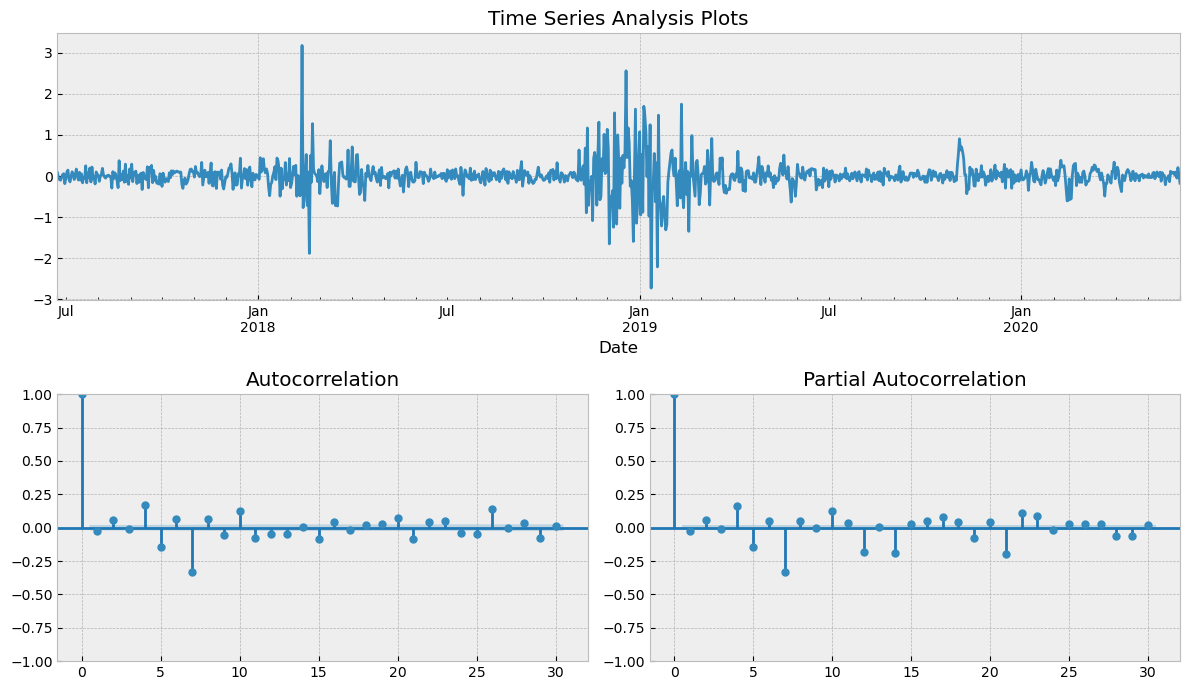

In [44]:
tsplot(best_model_rolling.resid[1:], lags=30)

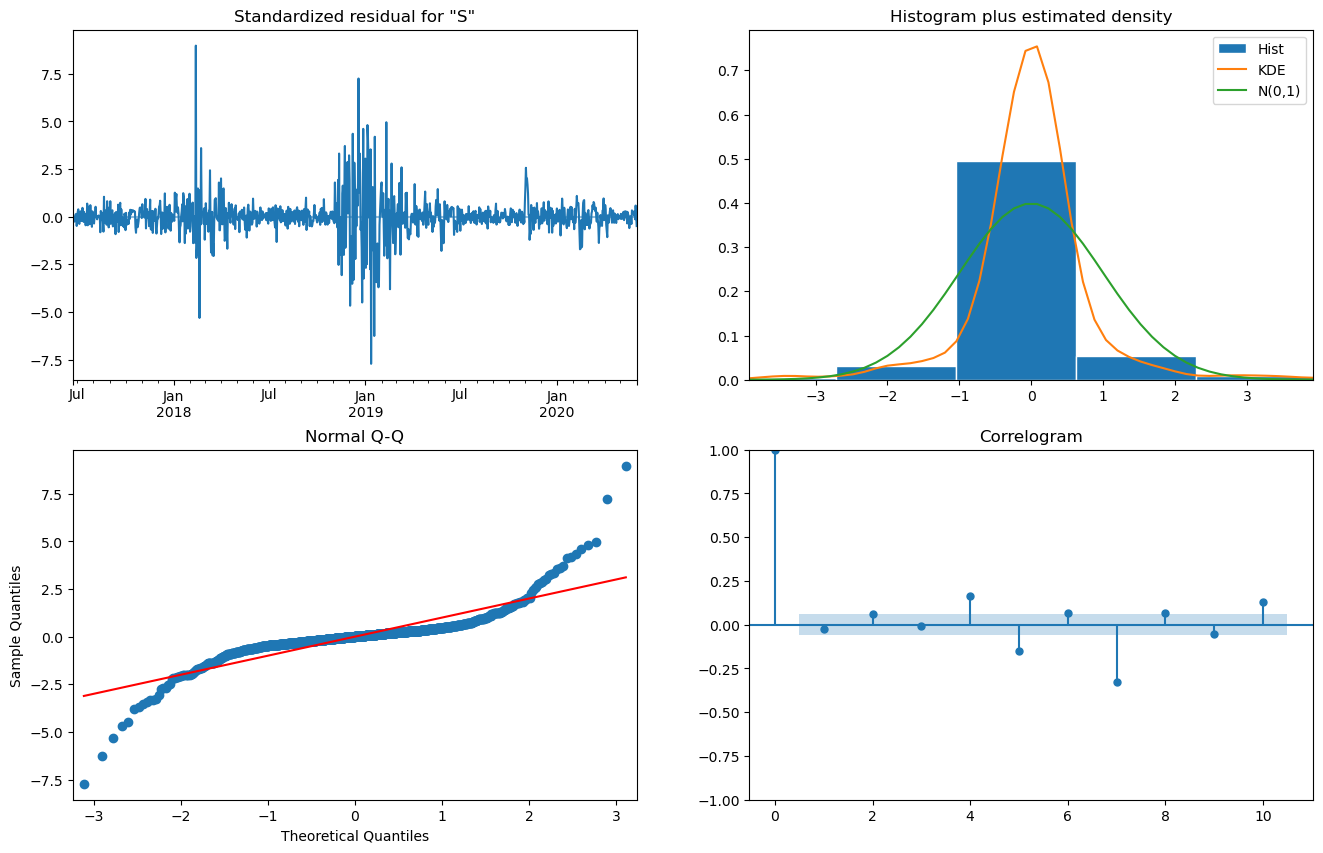

In [45]:
best_model_rolling.plot_diagnostics(figsize=(16, 10))
plt.show()

In [46]:
SO2_rolling_dataframe = pd.DataFrame()
SO2_rolling_dataframe['SO2_seen_data'] = pd.DataFrame(SO2_data_rolling_for_model)
SO2_rolling_dataframe["predict_for_seen_data"] = best_model_rolling.fittedvalues
forecast = pd.DataFrame({'predict_for_unseen_data': best_model_rolling.predict(start = SO2_data_rolling_for_model.shape[0]-1, end = SO2_data_rolling.shape[0])})
unseen_data = pd.DataFrame({'SO2_unseen_data': SO2_data_rolling.SO2['2020-06-01':]})
SO2_rolling_dataframe = SO2_rolling_dataframe.join(unseen_data, how = 'outer')
SO2_rolling_dataframe = SO2_rolling_dataframe.join(forecast)

SARIMA model
 Mean absolute error seen data: 3.95%
 Mean absolute error unseen data: 8.62%


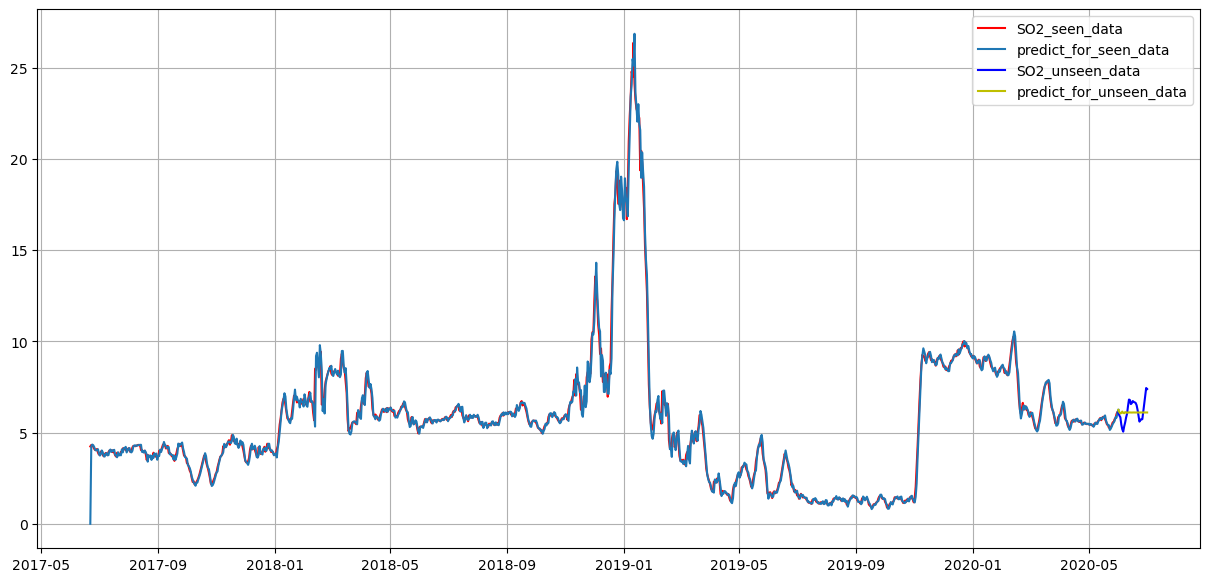

In [47]:
#SO2_data_rolling_for_model.shape[0]
make_final_plot(SO2_rolling_dataframe)

Получившиеся теперь предсказания модели намного больше соответствуют модели. Таким образом можно сделать вывод о том, что при наличии выбросов в данных сглаживание помогает улучшить качество